# EDA — Dataset_3772

Phase 2 exploratory data analysis for **Dataset_3772** 

In this notebook we run:
1. Data loading (index column and constant features dropped)
2. Visualization: Histogram + KDE, Boxplot, QQ-Plot, Pair Plot, correlation heatmaps
3. Descriptive statistics
4. Normality tests: Shapiro-Wilk, Anderson-Darling, Kolmogorov-Smirnov
5. Correlation tests: Pearson, Spearman, Kendall (+ bootstrap CIs for Kendall)
6. Outlier detection: IQR + LOF + Isolation Forest — *flag only, no row is removed*

All tables and figures are saved to `results/eda/Dataset_3772/`.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if (Path.cwd() / '..' / 'src').resolve().exists() else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import pandas as pd
from IPython.display import Image, display

from src.config import get_path
from src.data.loader import load_dataset
from src.eda.visualization import run_all_visualizations
from src.eda.statistics import (descriptive_statistics, normality_tests,
                                correlation_tests, kendall_ci_table)
from src.eda.outliers import outlier_report

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 250)

DATASET_NAME = 'Dataset_3772'
OUT_DIR = get_path('results_dir') / 'eda' / DATASET_NAME
print('EDA outputs will be saved to:', OUT_DIR)

EDA outputs will be saved to: C:\Users\mohammadhosein\Desktop\DeepLearning-miniProject\results\eda\Dataset_3772


Loading the dataset; the loader drops the constant input features.

In [2]:
bundle = load_dataset(DATASET_NAME)
df = pd.concat([bundle.X, bundle.Y], axis=1)
print('Shape:', df.shape)
print('Inputs :', bundle.feature_names)
print('Outputs:', bundle.output_names)
print('Dropped constant features:', bundle.dropped_constant_features)
df.head()

Shape: (36, 8)
Inputs : ['Tool Shape', 'Rotational Speed', 'Plunging Speed']
Outputs: ['Si Particle Size (um)', 'Hardness (HV)', 'wear rate', 'Ultimate Compression Strength (MPa)', 'Elongation (%)']
Dropped constant features: ['Composite Volume Fraction (%)']


,Tool Shape,Rotational Speed,Plunging Speed,Si Particle Size (um),Hardness (HV),wear rate,Ultimate Compression Strength (MPa),Elongation (%)
0,1,315,25.0,0.73,80,6.034,135.70,13.0
1,1,315,31.5,0.85,77,6.517,155.25,15.6
2,1,315,40.0,1.00,75,7.294,136.85,12.0
3,1,500,25.0,0.55,85,5.705,132.50,14.4
4,1,500,31.5,0.68,80,5.978,156.40,15.6


Generate and save all EDA figures for this dataset.

In [3]:
run_all_visualizations(df, OUT_DIR)
print('Figures saved to:', OUT_DIR)

Figures saved to: C:\Users\mohammadhosein\Desktop\DeepLearning-miniProject\results\eda\Dataset_3772


Histogram + KDE for every numeric variable.

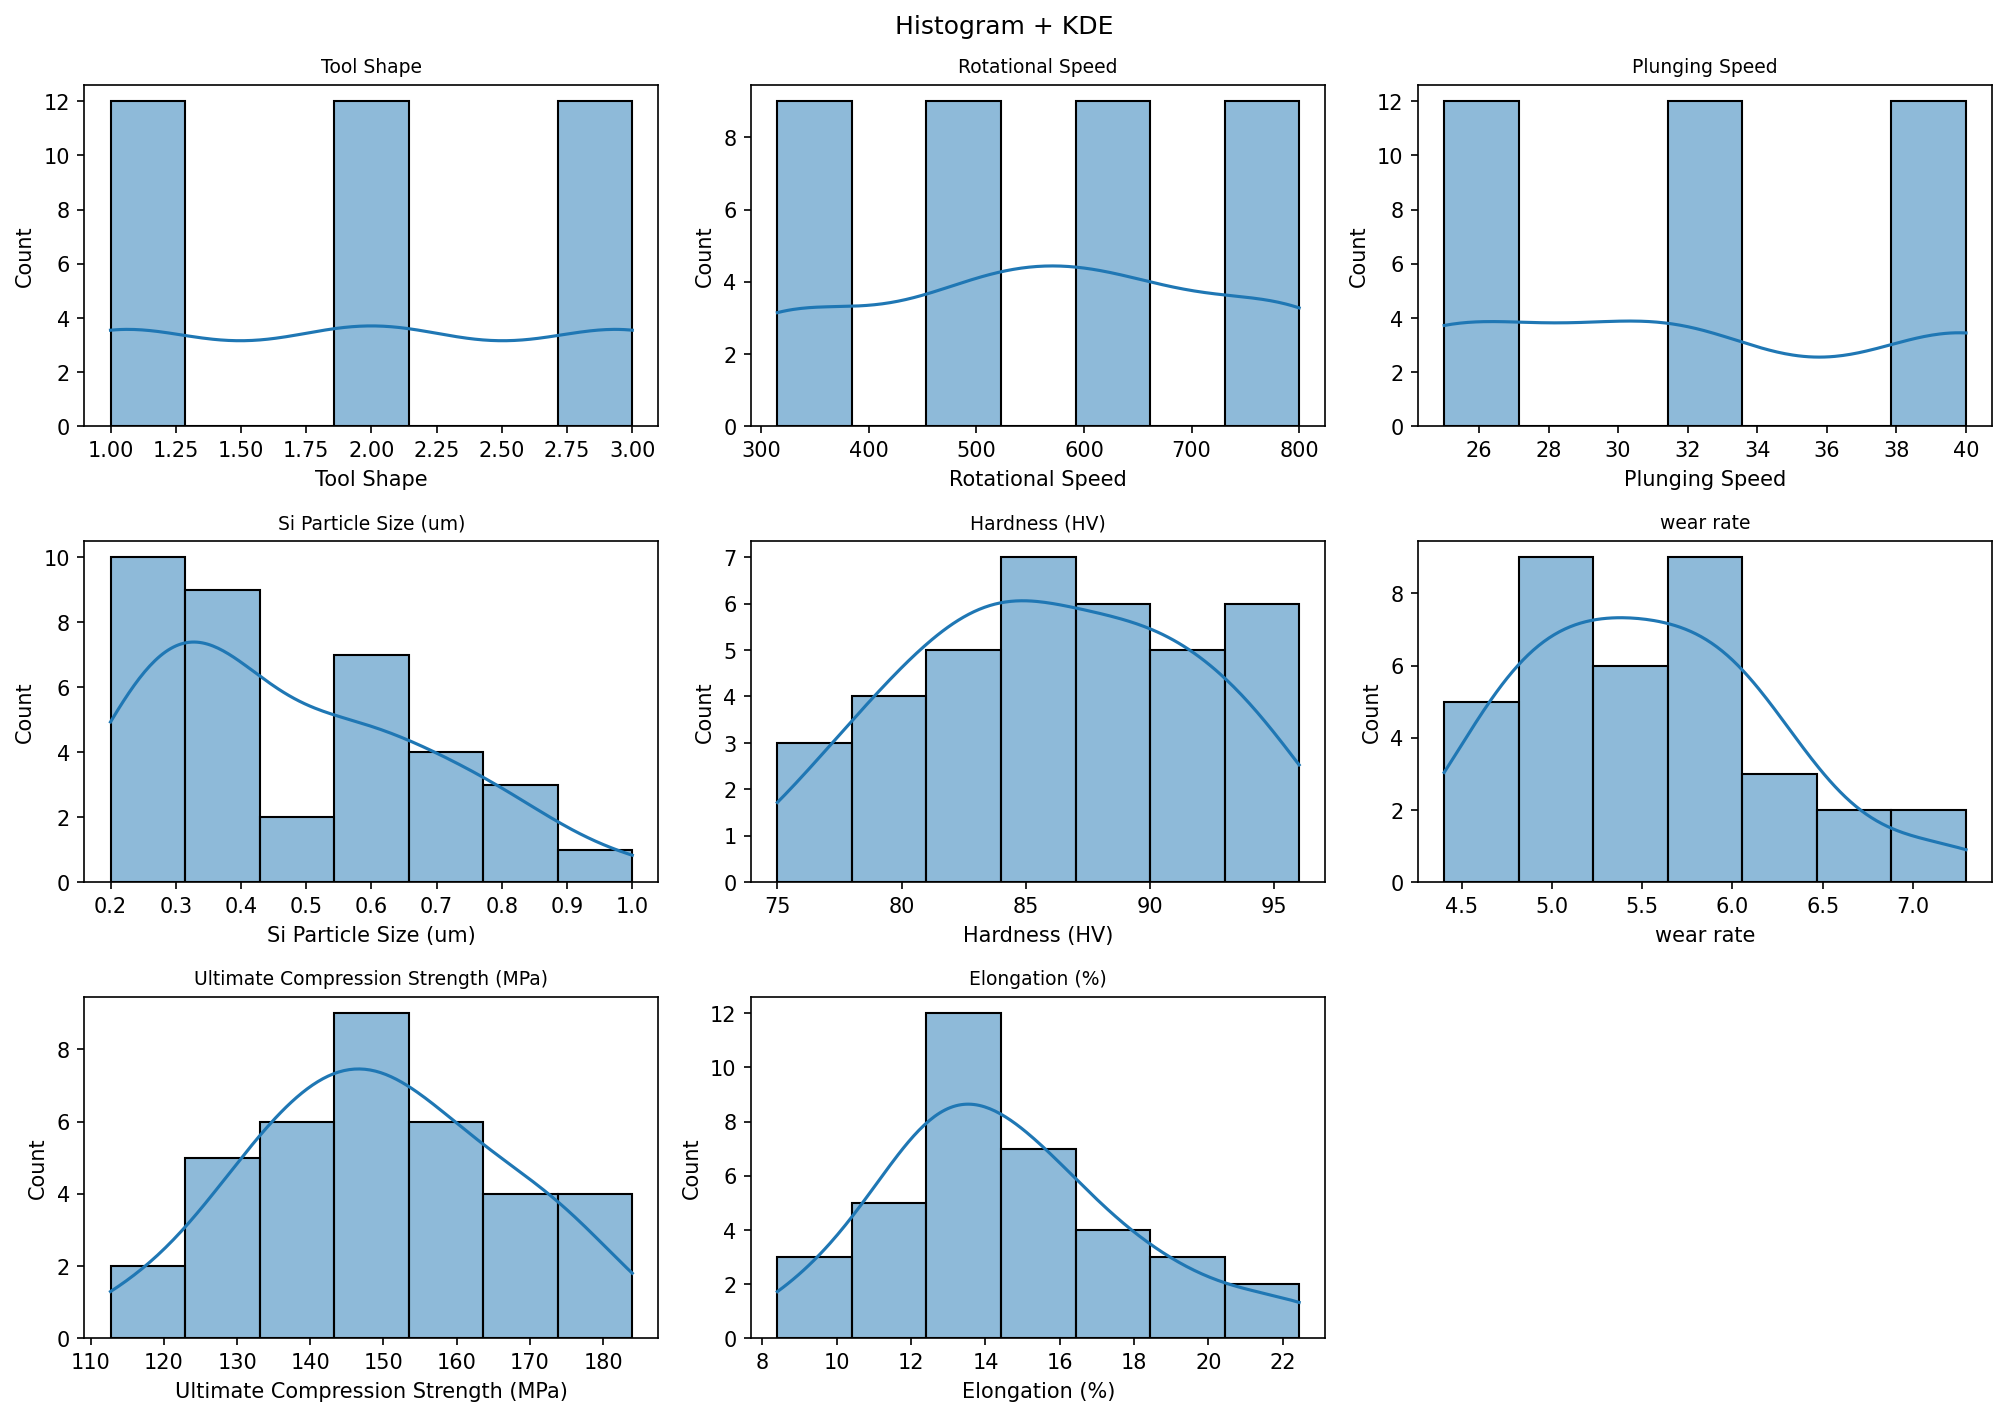

In [4]:
display(Image(filename=str(OUT_DIR / 'histograms_kde.png')))

Boxplot for every numeric variable.

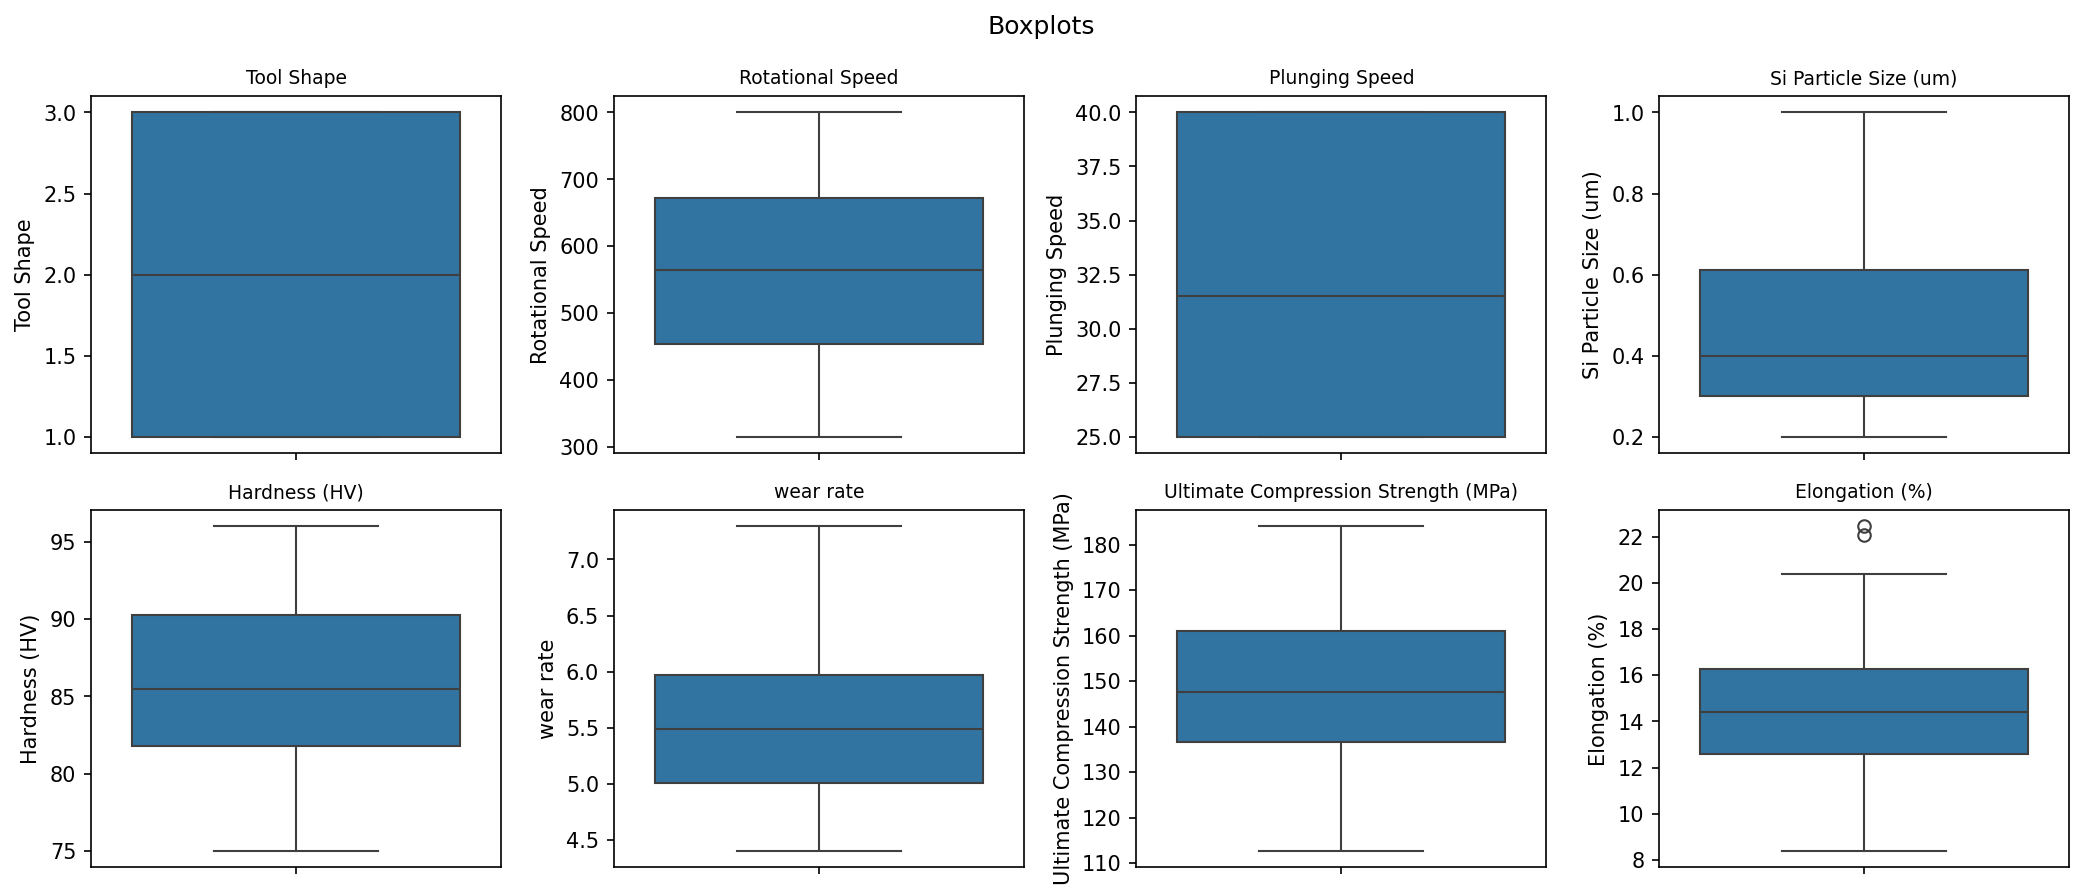

In [5]:
display(Image(filename=str(OUT_DIR / 'boxplots.png')))

QQ-plots against the normal distribution.

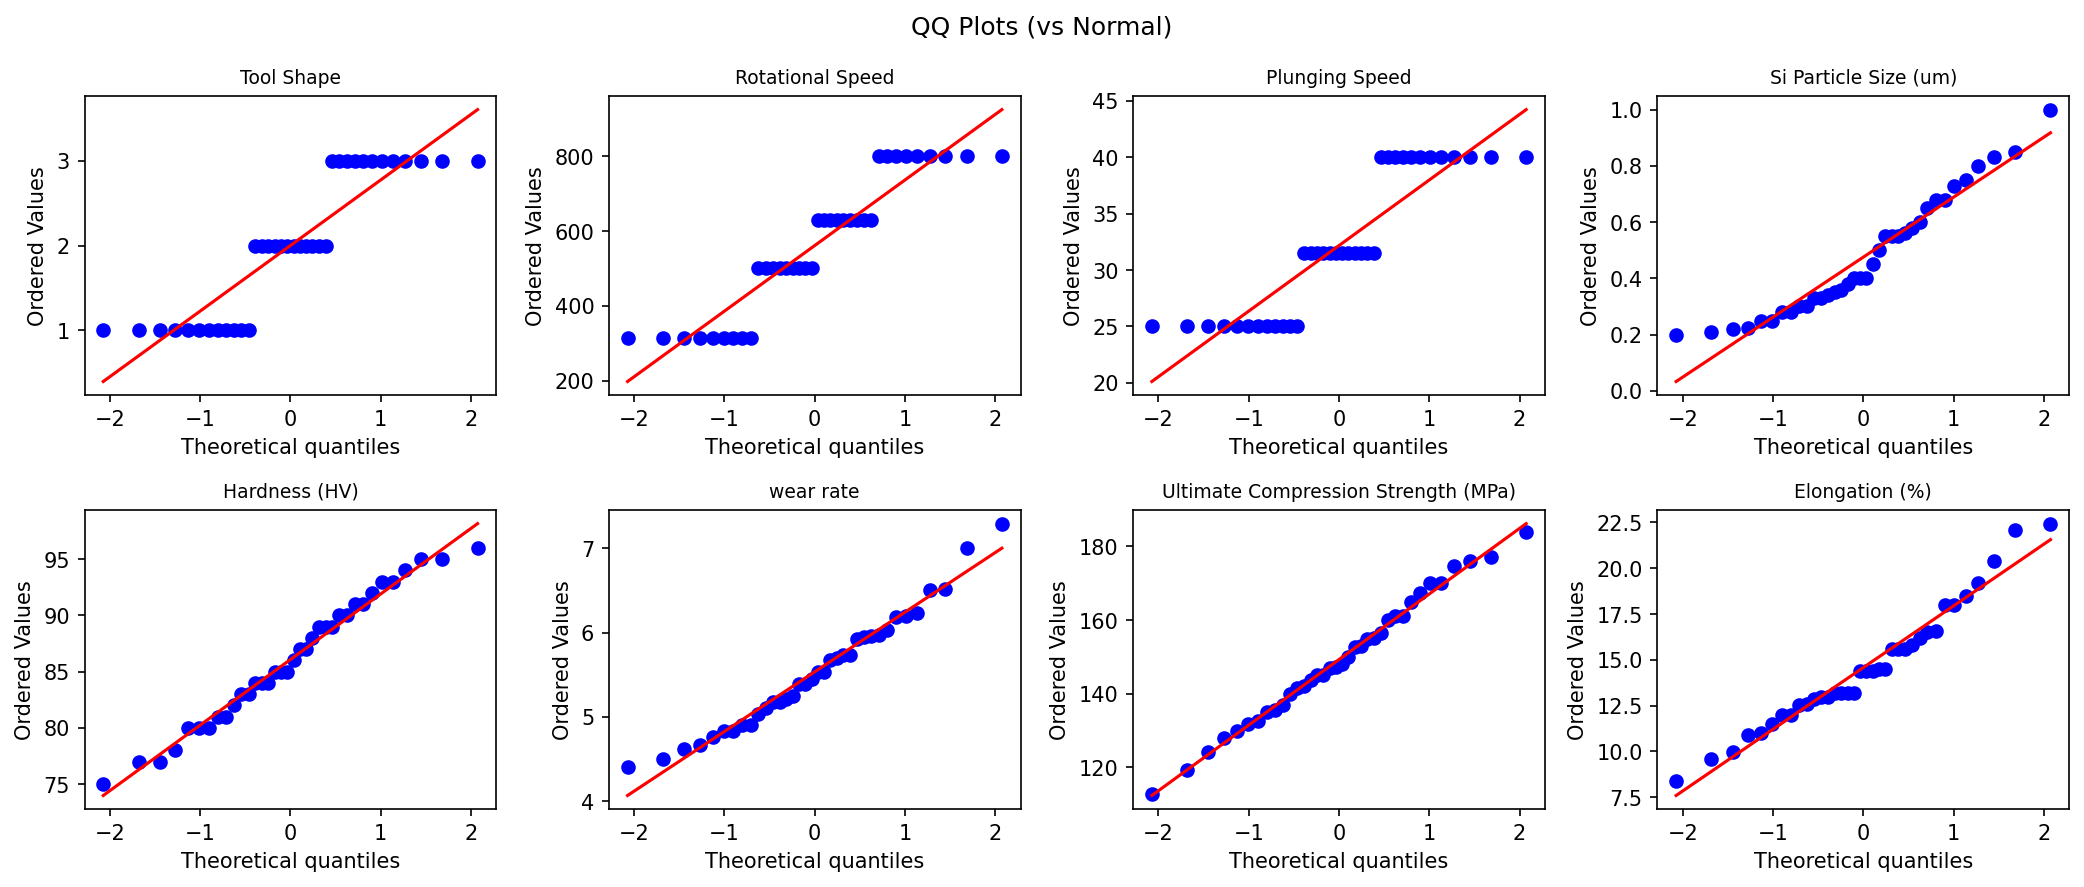

In [6]:
display(Image(filename=str(OUT_DIR / 'qq_plots.png')))

Pair plot of all numeric variables.

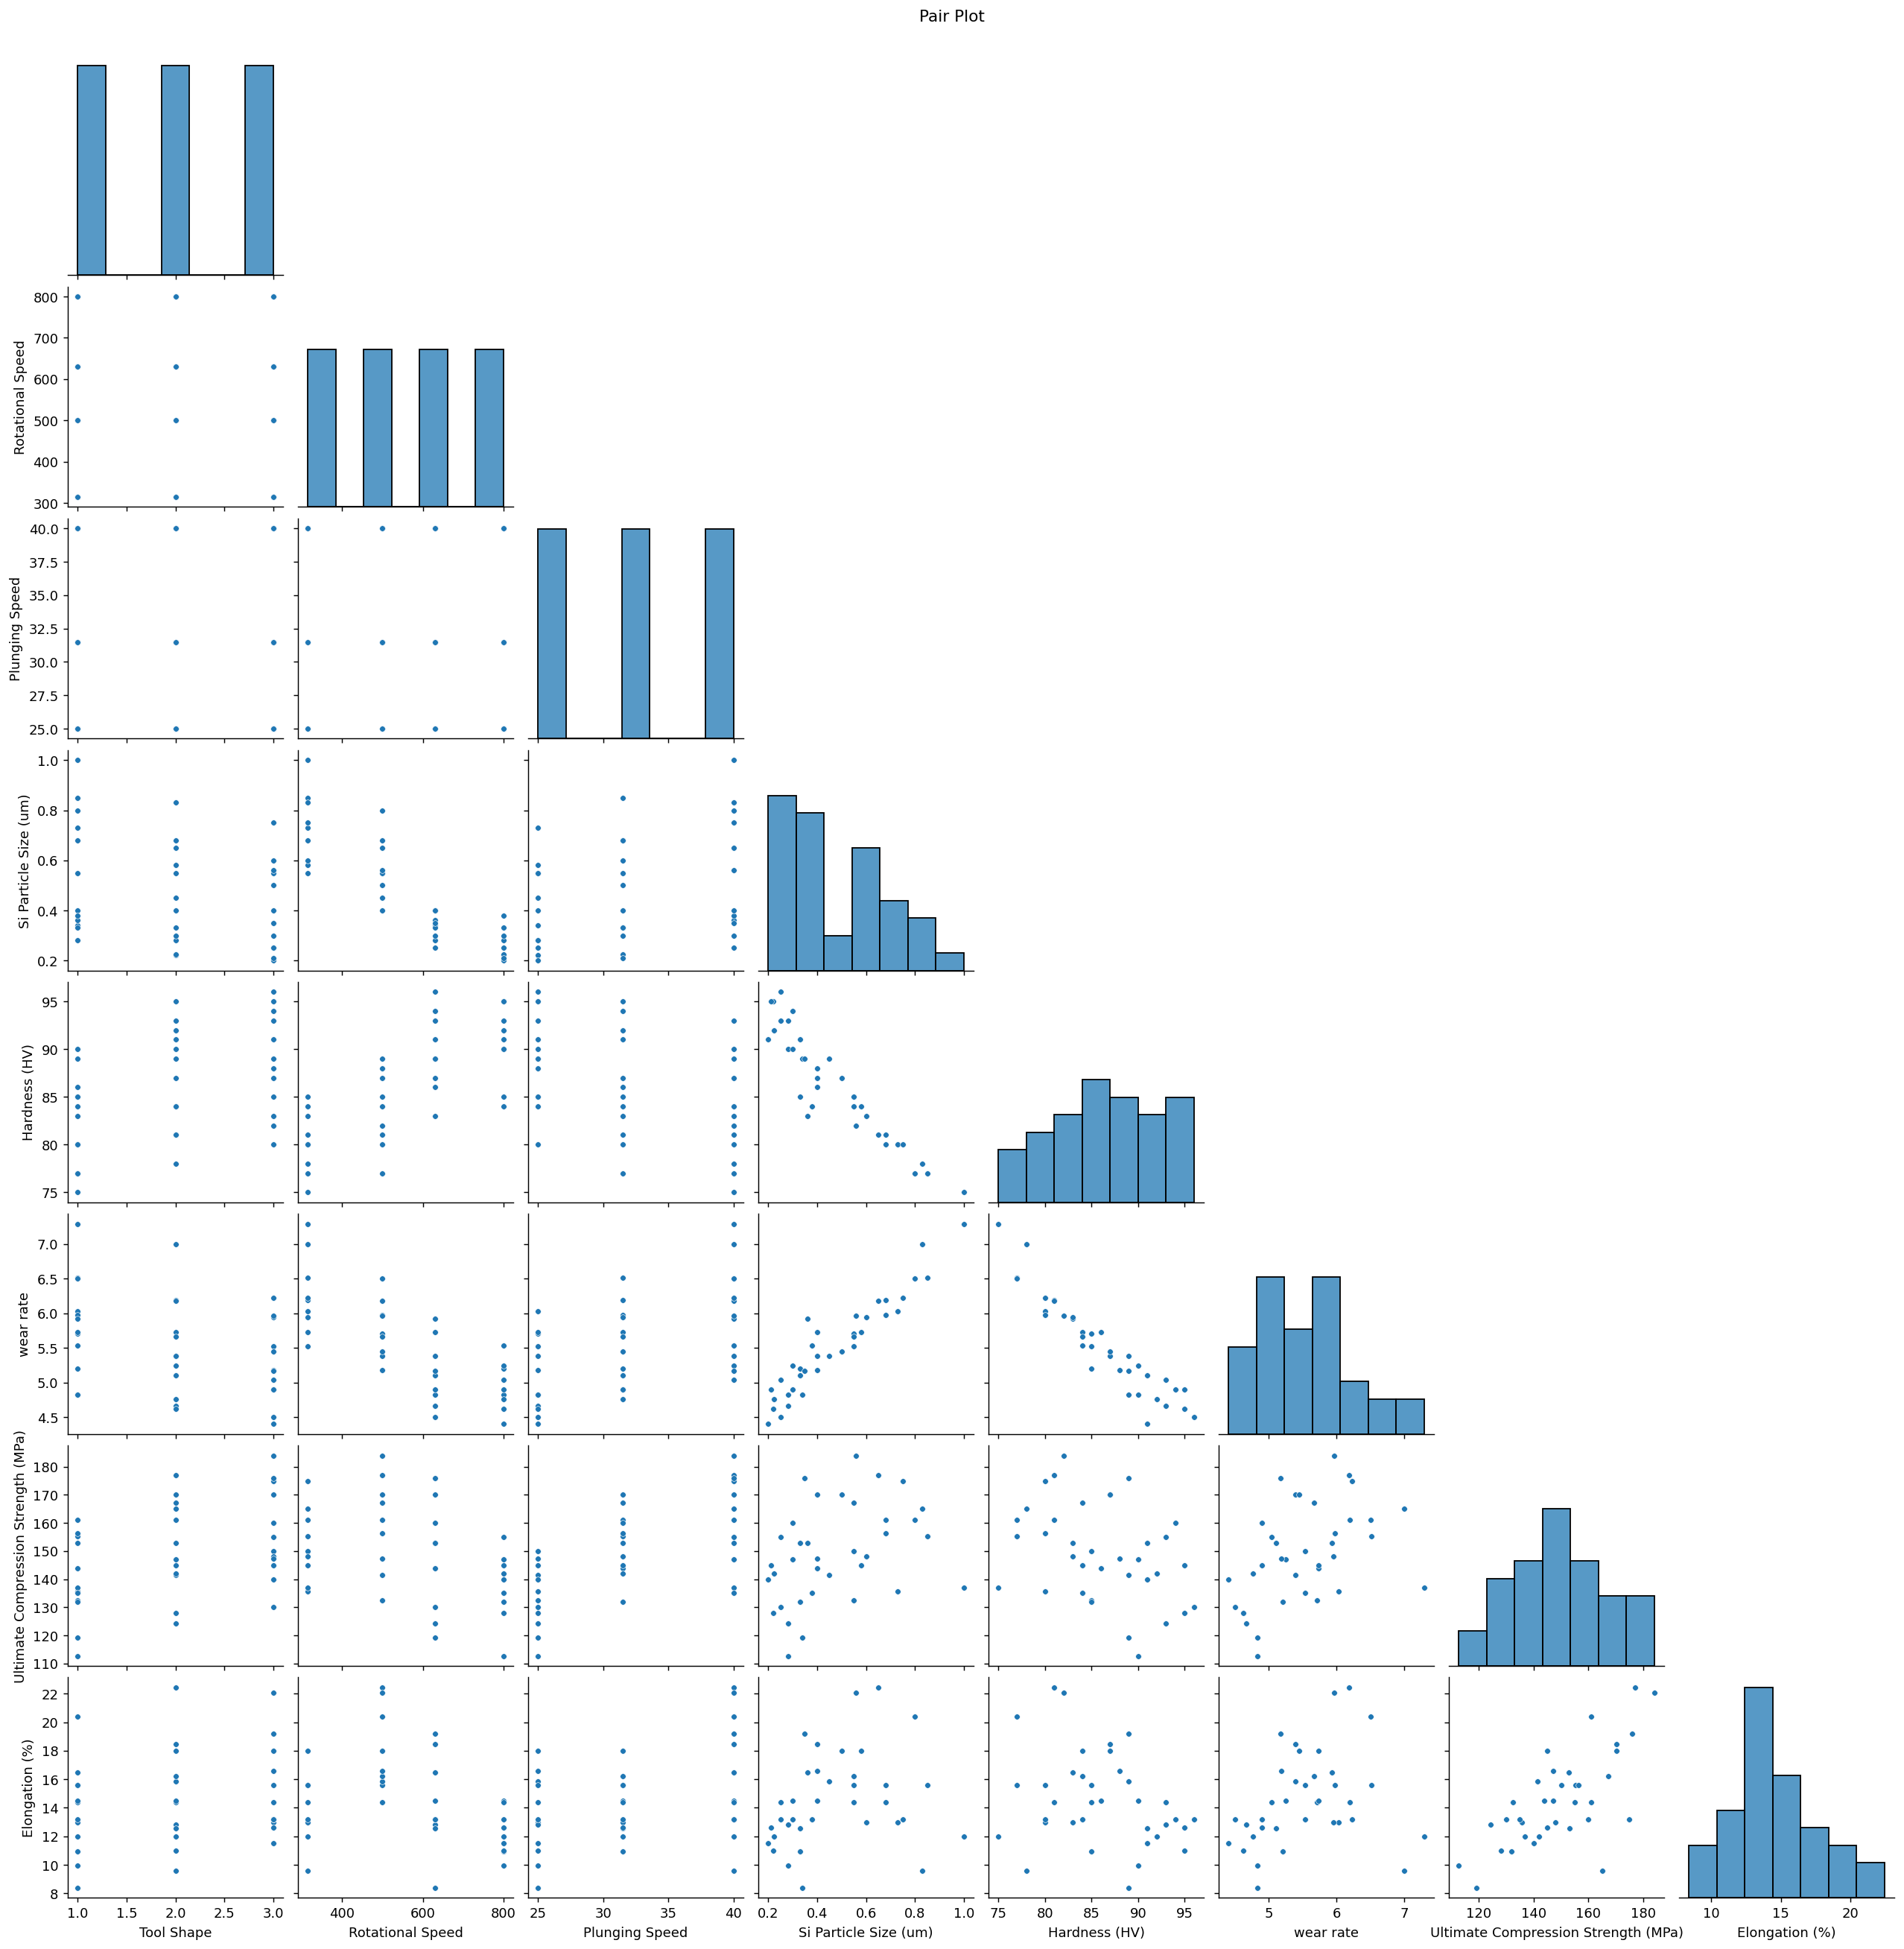

In [7]:
display(Image(filename=str(OUT_DIR / 'pairplot.png')))

Pearson / Spearman / Kendall correlation heatmaps.

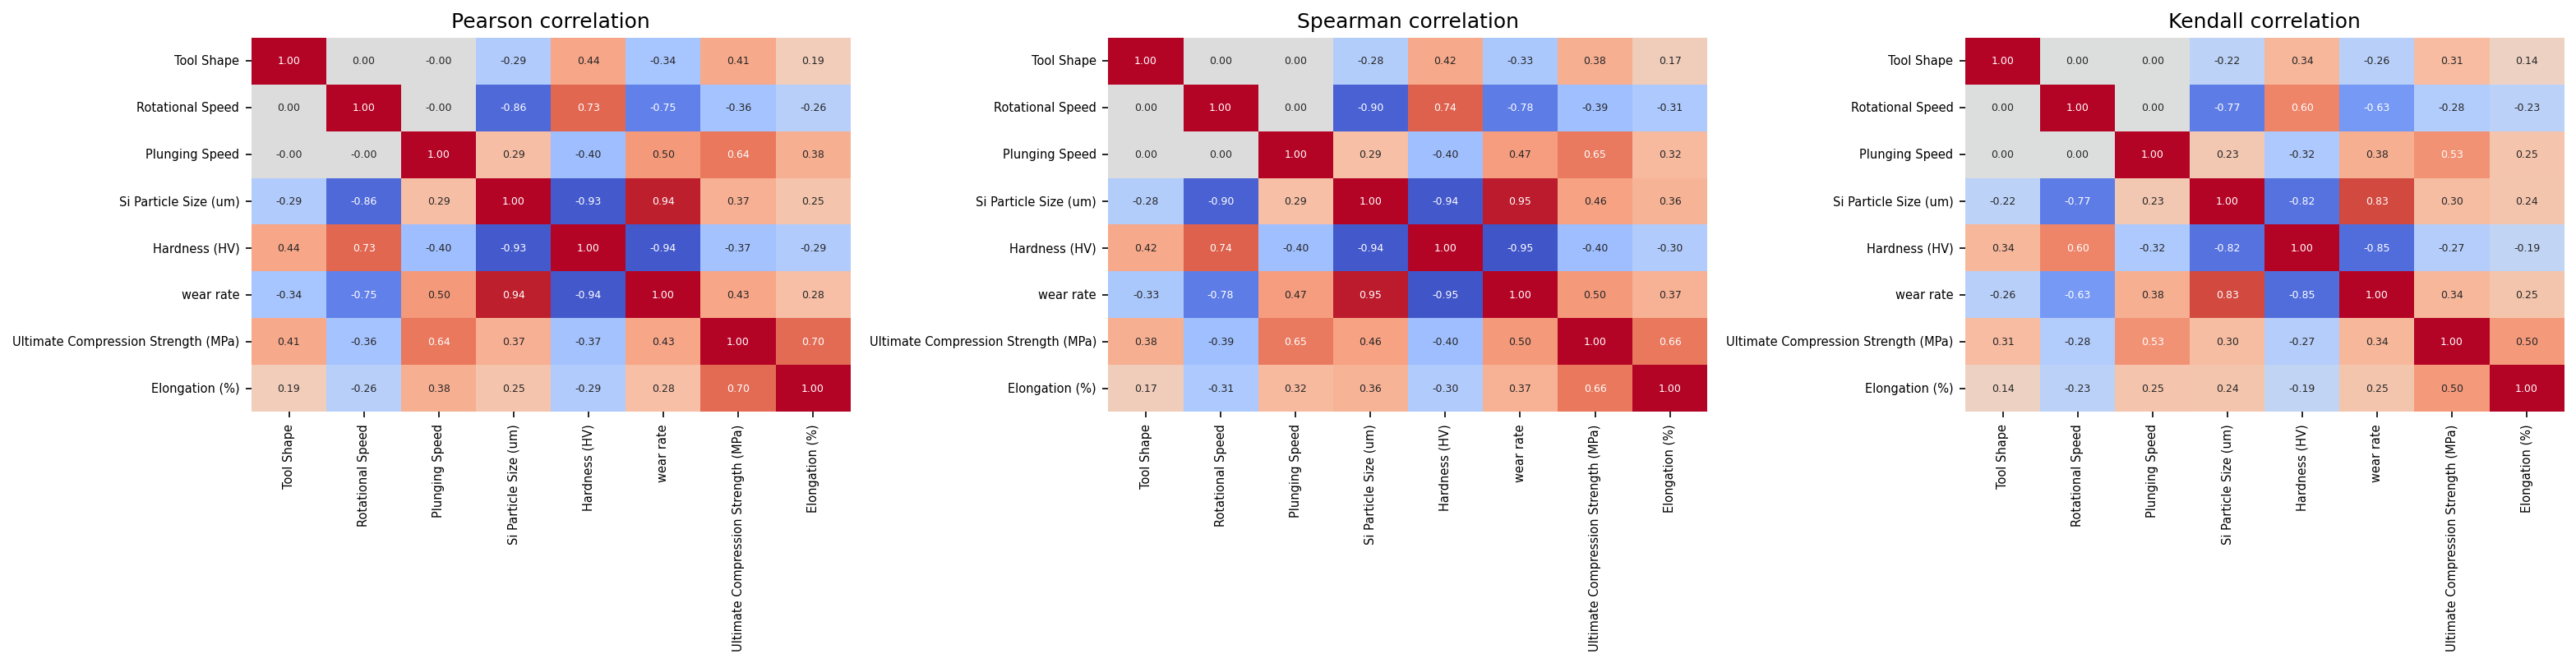

In [8]:
display(Image(filename=str(OUT_DIR / 'correlation_heatmaps.png')))

Descriptive statistics: mean, median, mode, variance, std, skewness, kurtosis.

In [9]:
desc = descriptive_statistics(df)
desc.to_csv(OUT_DIR / 'descriptive_statistics.csv')
desc

,mean,median,mode,variance,std,skewness,kurtosis,min,max
Tool Shape,2.0000,2.000,1.0,0.6857,0.8281,0.0000,-1.5441,1.000,3.000
Rotational Speed,561.2500,565.000,315.0,32430.5357,180.0848,-0.0573,-1.2545,315.000,800.000
Plunging Speed,32.1667,31.500,25.0,38.8000,6.2290,0.1686,-1.5441,25.000,40.000
Si Particle Size (um),0.4754,0.400,0.4,0.0452,0.2126,0.6465,-0.4891,0.200,1.000
Hardness (HV),86.0833,85.500,80.0,32.2500,5.6789,-0.0471,-0.8995,75.000,96.000
wear rate,5.5356,5.488,4.9,0.4804,0.6931,0.5220,-0.0222,4.403,7.294
Ultimate Compression Strength (MPa),149.2925,147.600,145.0,297.9650,17.2617,0.0236,-0.5148,112.700,184.000
Elongation (%),14.5811,14.400,13.2,10.9716,3.3123,0.5910,0.1754,8.400,22.440


**Interpretation.** `Si Particle Size` here is right-skewed (0.65) like in the other two datasets, but its absolute scale is strikingly different: mean 0.48 µm over a 0.2–1.0 µm range, versus 1.91 µm (0.8–4.1 µm) in Dataset_0136, which shares the same process-input DOE but has `Composite Volume Fraction` fixed at 0 instead of 1. This is a direct, cross-dataset confirmation of the composite-strengthening effect already inferred from Dataset_0172's varying volume fraction: at 100% composite fraction (this dataset) the effective Si particle size is both smaller and less variable. `Elongation` (0.59) and `wear rate` (0.52) repeat the same mild right-skew pattern seen throughout the project; `Hardness` and `Ultimate Compression Strength` stay close to symmetric.

Normality tests: Shapiro-Wilk, Anderson-Darling, Kolmogorov-Smirnov.

In [10]:
norm = normality_tests(df)
norm.to_csv(OUT_DIR / 'normality_tests.csv', index=False)
norm

,variable,shapiro_stat,shapiro_p,anderson_stat,anderson_crit_5pct,ks_stat,ks_p,normal_at_5pct(shapiro)
0,Tool Shape,0.7945,0.0000,2.8596,0.721,0.2197,0.0525,False
1,Rotational Speed,0.8617,0.0004,1.6647,0.721,0.1643,0.2564,False
2,Plunging Speed,0.7899,0.0000,2.9571,0.721,0.2291,0.0384,False
3,Si Particle Size (um),0.9321,0.0289,0.8034,0.721,0.1664,0.2434,False
4,Hardness (HV),0.9738,0.5375,0.2462,0.721,0.0851,0.9369,True
5,wear rate,0.9713,0.4624,0.2595,0.721,0.0765,0.9737,True
6,Ultimate Compression Strength (MPa),0.9899,0.9818,0.1147,0.721,0.0576,0.9992,True
7,Elongation (%),0.9651,0.3068,0.4641,0.721,0.1339,0.4971,True


**Interpretation.** The three DOE inputs fail normality here for the same structural reason as in Dataset_0136 (discrete, repeated set points, identical statistics since the input design is shared between the two datasets). `Si Particle Size` is borderline-non-normal (Shapiro p = 0.029, just under 5%) — weaker evidence than the emphatic rejection in Dataset_0172 (p ≈ 0.00003), but in the opposite direction from Dataset_0136 where it comfortably passed (p = 0.070); with a fixed 100% volume fraction here there is no sub-population mixing, so this mild non-normality is best read as ordinary right-skew rather than a bimodality artifact. `Hardness`, `wear rate`, `Ultimate Compression Strength` and `Elongation` all pass comfortably (p = 0.31–0.98).

Correlation tests (Pearson, Spearman, Kendall), sorted by absolute Spearman rho.

In [11]:
corr = correlation_tests(df)
corr.to_csv(OUT_DIR / 'correlation_tests.csv', index=False)
corr.sort_values('spearman_rho', key=abs, ascending=False)

,var_a,var_b,pearson_r,pearson_p,spearman_rho,spearman_p,kendall_tau,kendall_p
22,Hardness (HV),wear rate,-0.9399,0.0000,-0.9546,0.0000,-0.8498,0.0000
19,Si Particle Size (um),wear rate,0.9426,0.0000,0.9482,0.0000,0.8324,0.0000
18,Si Particle Size (um),Hardness (HV),-0.9270,0.0000,-0.9363,0.0000,-0.8169,0.0000
8,Rotational Speed,Si Particle Size (um),-0.8611,0.0000,-0.8964,0.0000,-0.7749,0.0000
10,Rotational Speed,wear rate,-0.7510,0.0000,-0.7774,0.0000,-0.6263,0.0000
9,Rotational Speed,Hardness (HV),0.7256,0.0000,0.7438,0.0000,0.5987,0.0000
27,Ultimate Compression Strength (MPa),Elongation (%),0.7025,0.0000,0.6554,0.0000,0.5012,0.0000
16,Plunging Speed,Ultimate Compression Strength (MPa),0.6440,0.0000,0.6469,0.0000,0.5322,0.0001
25,wear rate,Ultimate Compression Strength (MPa),0.4321,0.0085,0.4960,0.0021,0.3363,0.0040
15,Plunging Speed,wear rate,0.4998,0.0019,0.4749,0.0034,0.3821,0.0039


**Interpretation.** Inputs remain mutually uncorrelated (orthogonal DOE). The same output cluster seen in the other two datasets reappears with almost identical strength: `Hardness` vs `wear rate` (r=-0.94, ρ=-0.95), `Si Particle Size` vs `wear rate` (r=0.94, ρ=0.95) and `Si Particle Size` vs `Hardness` (r=-0.93, ρ=-0.94) — this triangle of relationships is now confirmed **consistently across all three datasets** regardless of sample size or volume fraction, which is strong evidence it reflects genuine friction-process/composite mechanics rather than a sampling artifact in any one dataset.

`Rotational Speed` is again the main process driver, this time of `Si Particle Size` (r=-0.86) and `Hardness` (r=0.73) — the same direction and similar magnitude as in Dataset_0136 (r=-0.85 and r=0.75 respectively), which is expected since the two datasets share the same input DOE. `Ultimate Compression Strength` vs `Elongation` (r=0.70) and `Plunging Speed` vs `Ultimate Compression Strength` (r=0.64) round out the picture, consistent with Dataset_0172.

Bootstrap confidence intervals for Kendall's tau (95%).

In [12]:
kci = kendall_ci_table(df)
kci.to_csv(OUT_DIR / 'kendall_confidence_intervals.csv', index=False)
kci

,var_a,var_b,tau,p_value,ci_lower,ci_upper
0,Tool Shape,Rotational Speed,0.0000,1.0000,-0.3073,0.2810
1,Tool Shape,Plunging Speed,0.0000,1.0000,-0.3054,0.2834
2,Tool Shape,Si Particle Size (um),-0.2243,0.0921,-0.4556,0.0460
3,Tool Shape,Hardness (HV),0.3370,0.0119,0.1017,0.5506
4,Tool Shape,wear rate,-0.2573,0.0519,-0.4788,-0.0215
5,Tool Shape,Ultimate Compression Strength (MPa),0.3094,0.0195,0.0727,0.5160
6,Tool Shape,Elongation (%),0.1359,0.3091,-0.1285,0.3728
7,Rotational Speed,Plunging Speed,0.0000,1.0000,-0.2946,0.2923
8,Rotational Speed,Si Particle Size (um),-0.7749,0.0000,-0.8496,-0.6684
9,Rotational Speed,Hardness (HV),0.5987,0.0000,0.4273,0.7244


Outlier detection with IQR, LOF and Isolation Forest — samples are flagged, never removed.

In [13]:
outl = outlier_report(df)
outl.to_csv(OUT_DIR / 'outlier_report.csv')
flagged = outl[outl['n_methods_flagging'] > 0]
print(f'{len(flagged)} of {len(outl)} samples flagged by at least one method')
flagged

5 of 36 samples flagged by at least one method


,iqr_outlier,lof_outlier,iforest_outlier,n_methods_flagging
2,False,False,True,1
5,False,False,True,1
14,False,False,True,1
17,True,False,False,1
29,True,False,True,2


**Interpretation.** 5/36 samples (14%) are flagged. Row 29 is the only one with 2-method agreement (IQR + Isolation Forest) and is the strongest outlier candidate in this dataset; row 17 is flagged by IQR alone (not Isolation Forest), the same "univariate-fence-but-not-multivariate" pattern seen for row 53 in Dataset_0172. LOF again flags nothing. As with the other two datasets, **no row is removed**: this is a designed mechanical experiment, and a handful of single-method flags at the edges of the process-parameter space is the expected behaviour of these detectors on small, structured DOE data, not evidence of faulty measurements.

## Summary — Dataset_3772

All result tables for this dataset, displayed in full (already saved as individual CSVs under `results/eda/Dataset_3772/`).

In [14]:
print('=' * 90)
print('1) DESCRIPTIVE STATISTICS')
print('=' * 90)
display(desc)

print('=' * 90)
print('2) NORMALITY TESTS')
print('=' * 90)
display(norm)

print('=' * 90)
print('3) CORRELATION TESTS (Pearson / Spearman / Kendall)')
print('=' * 90)
display(corr)

print('=' * 90)
print('4) KENDALL TAU BOOTSTRAP CONFIDENCE INTERVALS')
print('=' * 90)
display(kci)

print('=' * 90)
print('5) OUTLIER REPORT (flagged only, nothing removed)')
print('=' * 90)
display(outl)
n_flagged = int((outl['n_methods_flagging'] > 0).sum())
print(f'\n{n_flagged}/{len(outl)} samples flagged by at least one method '
      f'(IQR / LOF / Isolation Forest). No row is removed.')

print('\nAll EDA results (figures + CSV tables) saved to:', OUT_DIR.resolve())

1) DESCRIPTIVE STATISTICS


,mean,median,mode,variance,std,skewness,kurtosis,min,max
Tool Shape,2.0000,2.000,1.0,0.6857,0.8281,0.0000,-1.5441,1.000,3.000
Rotational Speed,561.2500,565.000,315.0,32430.5357,180.0848,-0.0573,-1.2545,315.000,800.000
Plunging Speed,32.1667,31.500,25.0,38.8000,6.2290,0.1686,-1.5441,25.000,40.000
Si Particle Size (um),0.4754,0.400,0.4,0.0452,0.2126,0.6465,-0.4891,0.200,1.000
Hardness (HV),86.0833,85.500,80.0,32.2500,5.6789,-0.0471,-0.8995,75.000,96.000
wear rate,5.5356,5.488,4.9,0.4804,0.6931,0.5220,-0.0222,4.403,7.294
Ultimate Compression Strength (MPa),149.2925,147.600,145.0,297.9650,17.2617,0.0236,-0.5148,112.700,184.000
Elongation (%),14.5811,14.400,13.2,10.9716,3.3123,0.5910,0.1754,8.400,22.440


2) NORMALITY TESTS


,variable,shapiro_stat,shapiro_p,anderson_stat,anderson_crit_5pct,ks_stat,ks_p,normal_at_5pct(shapiro)
0,Tool Shape,0.7945,0.0000,2.8596,0.721,0.2197,0.0525,False
1,Rotational Speed,0.8617,0.0004,1.6647,0.721,0.1643,0.2564,False
2,Plunging Speed,0.7899,0.0000,2.9571,0.721,0.2291,0.0384,False
3,Si Particle Size (um),0.9321,0.0289,0.8034,0.721,0.1664,0.2434,False
4,Hardness (HV),0.9738,0.5375,0.2462,0.721,0.0851,0.9369,True
5,wear rate,0.9713,0.4624,0.2595,0.721,0.0765,0.9737,True
6,Ultimate Compression Strength (MPa),0.9899,0.9818,0.1147,0.721,0.0576,0.9992,True
7,Elongation (%),0.9651,0.3068,0.4641,0.721,0.1339,0.4971,True


3) CORRELATION TESTS (Pearson / Spearman / Kendall)


...

4) KENDALL TAU BOOTSTRAP CONFIDENCE INTERVALS


,var_a,var_b,tau,p_value,ci_lower,ci_upper
0,Tool Shape,Rotational Speed,0.0000,1.0000,-0.3073,0.2810
1,Tool Shape,Plunging Speed,0.0000,1.0000,-0.3054,0.2834
2,Tool Shape,Si Particle Size (um),-0.2243,0.0921,-0.4556,0.0460
3,Tool Shape,Hardness (HV),0.3370,0.0119,0.1017,0.5506
4,Tool Shape,wear rate,-0.2573,0.0519,-0.4788,-0.0215
5,Tool Shape,Ultimate Compression Strength (MPa),0.3094,0.0195,0.0727,0.5160
6,Tool Shape,Elongation (%),0.1359,0.3091,-0.1285,0.3728
7,Rotational Speed,Plunging Speed,0.0000,1.0000,-0.2946,0.2923
8,Rotational Speed,Si Particle Size (um),-0.7749,0.0000,-0.8496,-0.6684
9,Rotational Speed,Hardness (HV),0.5987,0.0000,0.4273,0.7244


5) OUTLIER REPORT (flagged only, nothing removed)


,iqr_outlier,lof_outlier,iforest_outlier,n_methods_flagging
0,False,False,False,0
1,False,False,False,0
2,False,False,True,1
3,False,False,False,0
4,False,False,False,0
5,False,False,True,1
6,False,False,False,0
7,False,False,False,0
8,False,False,False,0
9,False,False,False,0



5/36 samples flagged by at least one method (IQR / LOF / Isolation Forest). No row is removed.

All EDA results (figures + CSV tables) saved to: C:\Users\mohammadhosein\Desktop\DeepLearning-miniProject\results\eda\Dataset_3772


## Key takeaways — Dataset_3772 (n=36, 100% composite volume fraction)

1. **Cross-dataset confirmation of the composite-strengthening effect:** at fixed 100% volume fraction, `Si Particle Size` is both smaller (mean 0.48 µm vs 1.91 µm) and less variable than in Dataset_0136 (fixed 0% fraction) — exactly the direction Dataset_0172's varying-fraction correlations predicted.
2. **The `Si Particle Size` ↔ `Hardness` ↔ `wear rate` triangle replicates across all three datasets** (|r| ≈ 0.93–0.96 everywhere), the single most robust, cross-dataset-confirmed physical relationship in the whole project and a natural focal point for the Level-B (shared-output) comparison and the SHAP dependence-plot interpretation in Phase 6.
3. **Same DOE inputs, same driver:** `Rotational Speed` reproduces almost the same correlation magnitudes with `Si Particle Size`/`Hardness` as in Dataset_0136 (identical input design), reinforcing that this driver relationship is a property of the process, not of one particular sample.
4. **Mild, single-method outliers only (5/36)** — none removed, same rationale as the other two datasets.
5. Together with Dataset_0136 and Dataset_0172, this closes the Level-A/Level-B picture: **Level A** (this notebook) analyses Dataset_3772 on its own five outputs; the shared-output trends confirmed here are exactly what the project's Level-B cross-dataset comparison (Section 4 of the final report) should quantify formally with the aggregated pipeline results.